## qsoabsfind example notebook

Below I show a few examples to run `qsoabsfind` explore its output.

In [1]:
# imports
import numpy as np
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt

## Running qsoabsfind as `bash` script

### Details of input file (DESI DR1 Spectra)

In [2]:
# exploring ..data/desi/qso_test_spectra.fits file
hdul = fits.open(f'../data/desi/qso_test_spectra.fits')


I have already run `qsoabsfind` on `../data/desi/qso_test_spectra.fits` and saved the results as `../data/desi/MgII_cat.fits`. In case you want to run, please do it by changing the `--output`

### Example run

In [3]:
# ! export absorber='MgII'
# !qsoabsfind  --input-fits-file ../data/qso_test.fits \
#              --output ../data/${absorber}_cat.fits\
#              --absorber ${absorber} \
#              --n-tasks 4 --ncpus 4 \
#              --headers AUTHOR=ABHIJEET SURVEY=desi 

### Exploring output

Text(0.5, 0, 'MgII redshift')

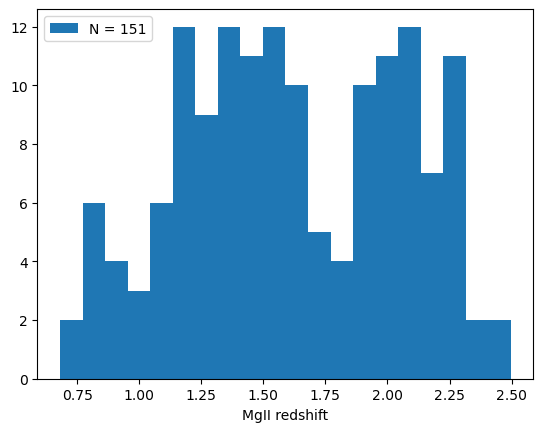

In [4]:
mgii_tab = Table.read(f'../data/desi/MgII_cat.fits', hdu=1)
zabs = mgii_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('MgII redshift')

Text(0.5, 0, '$EW_{\\rm MgII}\\, [\\AA]$')

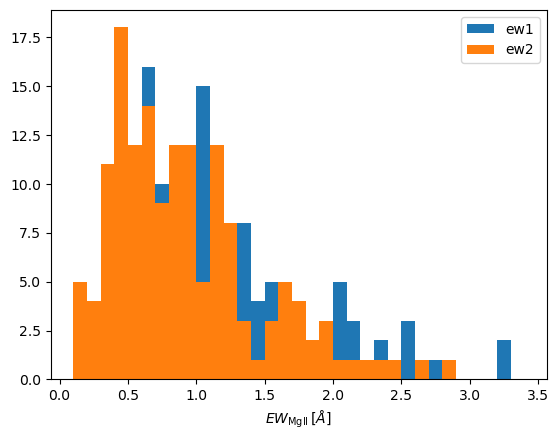

In [5]:
ew1 = mgii_tab["MGII_2796_EW"].data
ew2 = mgii_tab["MGII_2803_EW"].data
bins = np.arange(0.1, 3.5, 0.1)
plt.hist(ew1, bins=bins, label='ew1')
plt.hist(ew2, bins=bins, label = 'ew2')
plt.legend()
plt.xlabel(r'$EW_{\rm MgII}\, [\AA]$')

### Plotting spectra


INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.10 seconds


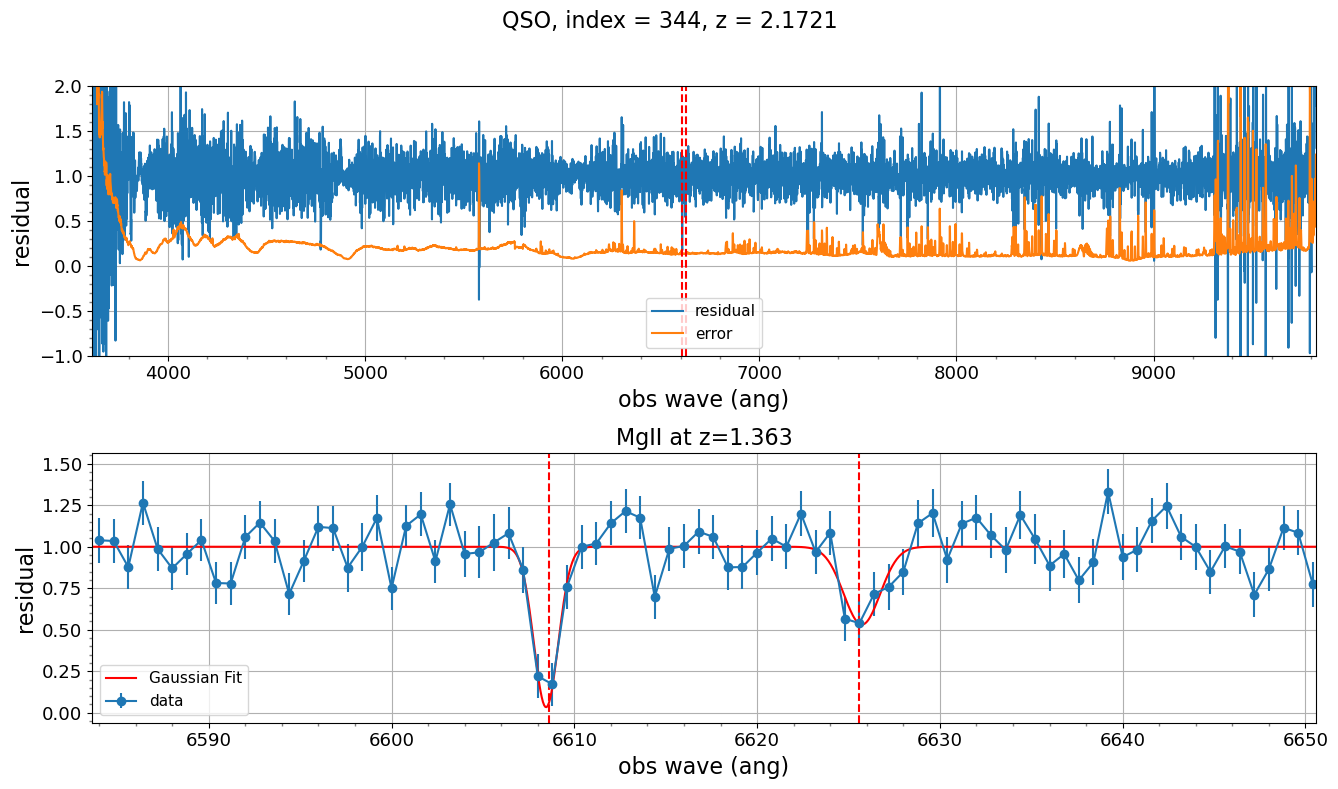

In [7]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead
import numpy as np

# select a random spectra from MgII_cat.fits
index = np.random.choice(mgii_tab["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = mgii_tab[mgii_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'MgII', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z"]:.4f}', plot_filename=None)

### Using qsoabsfind internally as module

In [8]:
# if want to run qsoabsfind on one spectrum
from qsoabsfind.absfinder import read_single_spectrum_and_find_absorber
from qsoabsfind.constants import search_parameters
help(read_single_spectrum_and_find_absorber)

Help on function read_single_spectrum_and_find_absorber in module qsoabsfind.absfinder:

read_single_spectrum_and_find_absorber(fits_file, spec_index, absorber, **kwargs)
    This function retrieves a single QSO spectrum from a FITS file, processes the data to remove NaNs,
    and prepares the spectrum for absorber search within specified wavelength regions
    and runs the convolution based adaptive S/N method to detect absorbers in the spectrum.
    
    Args:
        fits_file (str): Path to the FITS file containing normalized QSO spectra.
                         The file must include extensions for FLUX, ERROR, WAVELENGTH
                         and METADATA which must contain keyword Z_QSO.
        spec_index (int): Index of the quasar spectrum to retrieve from the FITS file.
        absorber (str): Name of the absorber to search for (e.g., 'MgII', 'CIV').
        kwargs (dict): search parameters as described in qsoabsfind.constants()
    
    Returns:
        tuple: Contains li

In [11]:
read_single_spectrum_and_find_absorber(f'../data/desi/qso_test_spectra.fits', 23, 'MgII', **search_parameters["MgII"])


INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.09 seconds

INFO: Time taken to finish MgII detection for index = 23 Quasar is:  1.28 seconds


([23],
 [1.683304429587356],
 [[0.11031926749718587,
   2796.3933402230227,
   0.9607119254465962,
   0.13424372411210025,
   2803.1813348221517,
   0.6477358197698404]],
 [[0.07209395844953623,
   0.7195272191876912,
   0.7220439980429199,
   0.07812404063764802,
   0.4665589597167229,
   0.5194235003439971]],
 [0.26566508412361145],
 [0.21796253323554993],
 [0.4836276173591614],
 [0.026053491979837418],
 [0.04794078320264816],
 [0.05456283688545227],
 [0.00044040277134627104],
 [4.251699104983581],
 [3.976085170827375],
 [76.56133053302176],
 [6.668651118403781])

Text(0.5, 0, 'CIV redshift')

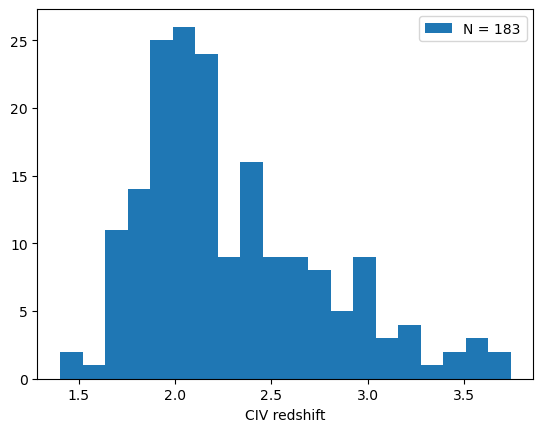

In [12]:
abs_tab = Table.read(f'../data/desi/CIV_cat.fits', hdu=1)
zabs = abs_tab["Z_ABS"].data
plt.hist(zabs, bins=20, label = f'N = {zabs.size}')
plt.legend()
plt.xlabel('CIV redshift')


INFO: Time taken to read ../data/desi/qso_test_spectra.fits 0.08 seconds


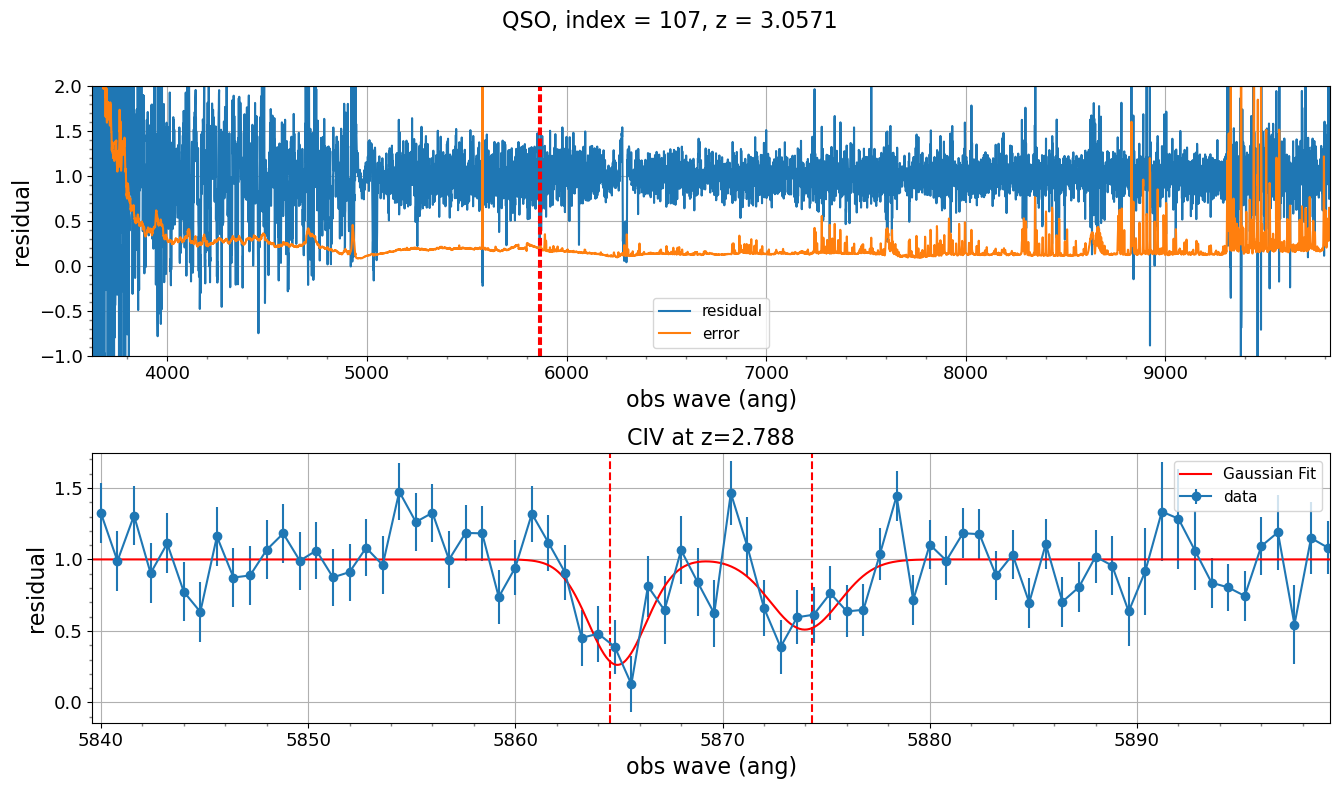

In [14]:
from qsoabsfind.utils import plot_absorber
from qsoabsfind.spec import QSOSpecRead

# select a random spectra from MgII_cat.fits
index = np.random.choice(abs_tab["INDEX_SPEC"].data)
spectra = QSOSpecRead(f'../data/desi/qso_test_spectra.fits', index=index, autoload=True)

# select corresponding zabs table
zabs = abs_tab[abs_tab["INDEX_SPEC"].data==index]
plot_absorber(spectra, 'CIV', zabs, show_error=True, xlabel='obs wave (ang)', \
              ylabel='residual', title=f'QSO, index = {index}, z = {spectra.metadata["Z"]:.4f}', plot_filename=None)